In [490]:
import os
os.chdir(r'C:\Users\66959\Desktop\stats\data')
os.getcwd()

'C:\\Users\\66959\\Desktop\\stats\\data'

In [491]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [492]:
orig_df1 = pd.read_csv('worldbank_gender_2021.csv')
orig_df2 = pd.read_excel('countries_regions.xlsx')

In [493]:
orig_df = pd.merge(orig_df1, orig_df2, left_on='Country Name', right_on='CountryName')

In [494]:
orig_df.head()

,Country Name,Year,Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),...,"Contributing family workers, male (% of male employment) (modeled ILO estimate)",Firms with female participation in ownership (% of firms),Firms with female top manager (% of firms),"Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)","Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)","Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)",Gender Ratio Class,CountryName,Region,ThirdWorld
0,Afghanistan,2021,6.51,58.74,33.60,12.00,2099.0,125.67,5.20,114.32,...,12.79,NaN,NaN,NaN,NaN,NaN,1.0,Afghanistan,South Asia,Yes
1,Albania,2021,16.54,41.47,18.36,21.89,5144.7,114.68,NaN,104.92,...,15.96,NaN,NaN,NaN,NaN,NaN,1.0,Albania,Eastern Europe,No
2,Algeria,2021,NaN,17.35,11.23,3.16,1433.7,108.76,20.68,104.83,...,1.61,NaN,NaN,NaN,NaN,NaN,1.0,Algeria,Africa,No
3,American Samoa,2021,NaN,14.50,NaN,4.85,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,American Samoa,Australia and Oceanea,No
4,Andorra,2021,NaN,39.91,0.53,1.59,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Andorra,Western Europe,No


In [495]:
orig_df = orig_df.drop(columns=['CountryName', 'Country Name', 'Year'])

In [496]:
orig_df['Gender Ratio Class'].value_counts()

Gender Ratio Class
2.0    57
5.0    44
1.0    33
3.0    31
4.0    19
Name: count, dtype: int64

In [497]:
df = orig_df.copy()

In [498]:
df.shape

(214, 196)

# Train-test split

In [499]:
X = df.drop(columns=["Gender Ratio Class"])
y = df["Gender Ratio Class"]

In [500]:
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

In [501]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99, stratify=y)

In [502]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Gender Ratio Class
2.0    0.312925
5.0    0.238095
1.0    0.176871
3.0    0.170068
4.0    0.102041
Name: proportion, dtype: float64
Gender Ratio Class
2.0    0.297297
5.0    0.243243
1.0    0.189189
3.0    0.162162
4.0    0.108108
Name: proportion, dtype: float64


In [503]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((147, 195), (37, 195), (147,), (37,))

# Data preprocessing 

## Handling missing values

In [504]:
print((X_train.isna().mean() * 100).to_string())

Agricultural irrigated land (% of total agricultural land)                                                                                      76.870748
Agricultural land (% of land area)                                                                                                               0.680272
Agriculture, forestry, and fishing, value added (% of GDP)                                                                                       7.482993
Arable land (% of land area)                                                                                                                     0.680272
Cereal yield (kg per hectare)                                                                                                                    7.482993
Crop production index (2014-2016 = 100)                                                                                                          2.040816
Fertilizer consumption (kilograms per hectare of arable land)               

In [505]:
print((y_train.isna().mean() * 100))

0.0


In [506]:
threshold = 0.4
missing_ratio = X_train.isna().mean()
drop_cols = missing_ratio[missing_ratio > threshold].index

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [507]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object','category']).columns

In [508]:
cat_cols

Index(['Region', 'ThirdWorld'], dtype='object')

In [509]:
X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())
X_test[num_cols] = X_test[num_cols].fillna(X_train[num_cols].median())

X_train[cat_cols] = X_train[cat_cols].fillna(X_train[cat_cols].mode())
X_test[cat_cols] = X_test[cat_cols].fillna(X_train[cat_cols].mode())

In [510]:
print((X_train.isna().mean() * 100).to_string())

Agricultural land (% of land area)                                                                 0.0
Agriculture, forestry, and fishing, value added (% of GDP)                                         0.0
Arable land (% of land area)                                                                       0.0
Cereal yield (kg per hectare)                                                                      0.0
Crop production index (2014-2016 = 100)                                                            0.0
Fertilizer consumption (kilograms per hectare of arable land)                                      0.0
Food production index (2014-2016 = 100)                                                            0.0
Forest area (% of land area)                                                                       0.0
Forest area (sq. km)                                                                               0.0
Land area (sq. km)                                                       

## Handling Skewness

In [511]:
skewness = X_train[num_cols].skew().sort_values(ascending=False)

threshold = 0.75
high_skew_columns = skewness[abs(skewness) > threshold].index.tolist()

skewness

Air transport, registered carrier departures worldwide                    9.519597
External debt stocks, total (DOD, current US$)                            9.380450
GDP (current US$)                                                         9.279551
Inflation, consumer prices (annual %)                                     8.889095
GDP growth (annual %)                                                     8.863020
                                                                            ...   
Primary completion rate, total (% of relevant age group)                 -1.778597
Access to electricity (% of population)                                  -1.805295
Net migration                                                            -2.122175
Adjusted net savings, including particulate emission damage (% of GNI)   -3.998760
Population, female (% of total population)                               -4.522141
Length: 95, dtype: float64

In [512]:
def fit_transform_skew(train_df, skew_cols):
    from sklearn.preprocessing import PowerTransformer
    train_res = train_df.copy()
    pt = PowerTransformer(method='yeo-johnson')
    train_res[skew_cols] = pt.fit_transform(train_df[skew_cols])
    return train_res, pt

In [513]:
X_train, pt_model = fit_transform_skew(X_train, high_skew_columns)
X_test[high_skew_columns] = pt_model.transform(X_test[high_skew_columns])

## Encoding

In [514]:
cat_cols

Index(['Region', 'ThirdWorld'], dtype='object')

In [515]:
X_train.shape

(147, 97)

In [516]:
def onehot_encoder_selected(df, encoded_vars):
    df = pd.get_dummies(df, columns=encoded_vars, drop_first=True)
    return df

In [517]:
X_train = onehot_encoder_selected(X_train, cat_cols)
X_test = onehot_encoder_selected(X_test, cat_cols)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [518]:
X_train.shape

(147, 108)

In [519]:
X_test.shape

(37, 108)

# Feature selection

In [520]:
X_train.head()

,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,Region_Middle East,Region_North America,Region_Northern Europe,Region_South America,Region_South Asia,Region_Southeast Asia,Region_Thailand,Region_Western Asia,Region_Western Europe,ThirdWorld_Yes
68,13.97,0.016564,-1.758870,0.030616,-0.211947,0.190214,-0.237209,43.06,-0.995483,-1.310775,...,False,False,False,False,False,False,False,False,False,False
26,28.64,-0.067612,-0.373879,0.526135,0.455221,1.177253,0.249205,59.27,2.844698,2.322591,...,False,False,False,True,False,False,False,False,False,False
5,36.81,0.479342,-0.771379,-1.275249,0.496942,-1.407487,0.539803,52.98,1.558742,1.125247,...,False,False,False,False,False,False,False,False,False,True
204,71.16,-1.543973,0.919917,1.194939,-0.886131,0.823744,-0.434964,13.22,0.081634,0.279008,...,False,False,True,False,False,False,False,False,False,False
210,64.93,-0.101886,-0.376411,-0.381236,0.548853,1.183018,0.533999,1.68,-1.687193,-1.144244,...,True,False,False,False,False,False,False,False,False,False


## Low Variance Filtering

In [521]:
X_train.var().sort_values(ascending=False)

Vulnerable employment, female (% of female employment) (modeled ILO estimate)    967.325455
School enrollment, tertiary (% gross)                                            600.754194
Vulnerable employment, male (% of male employment) (modeled ILO estimate)        575.290862
Urban population (% of total population)                                         566.700548
Rural population (% of total population)                                         566.699586
                                                                                    ...    
Region_Northern Europe                                                             0.051813
Region_East Asia                                                                   0.045662
Region_South Asia                                                                  0.045662
Region_Western Asia                                                                0.033082
Region_Thailand                                                                 

In [522]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)
selector.fit(X_train)

updated_vars = X_train.columns[selector.get_support()].tolist()
updated_vars

['Agricultural land (% of land area)',
 'Agriculture, forestry, and fishing, value added (% of GDP)',
 'Arable land (% of land area)',
 'Cereal yield (kg per hectare)',
 'Crop production index (2014-2016 = 100)',
 'Fertilizer consumption (kilograms per hectare of arable land)',
 'Food production index (2014-2016 = 100)',
 'Forest area (% of land area)',
 'Forest area (sq. km)',
 'Land area (sq. km)',
 'Livestock production index (2014-2016 = 100)',
 'Permanent cropland (% of land area)',
 'Rural population',
 'Rural population (% of total population)',
 'Surface area (sq. km)',
 'Access to electricity (% of population)',
 'Annual freshwater withdrawals, total (% of internal resources)',
 'Mortality rate, under-5 (per 1,000 live births)',
 'Population growth (annual %)',
 'Population in urban agglomerations of more than 1 million (% of total population)',
 'Population, total',
 'Primary completion rate, total (% of relevant age group)',
 'Renewable energy consumption (% of total final e

In [523]:
len(updated_vars)

108

In [524]:
X_train = X_train[updated_vars]
X_test = X_test[updated_vars]
X_train.head()

,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,Region_Middle East,Region_North America,Region_Northern Europe,Region_South America,Region_South Asia,Region_Southeast Asia,Region_Thailand,Region_Western Asia,Region_Western Europe,ThirdWorld_Yes
68,13.97,0.016564,-1.758870,0.030616,-0.211947,0.190214,-0.237209,43.06,-0.995483,-1.310775,...,False,False,False,False,False,False,False,False,False,False
26,28.64,-0.067612,-0.373879,0.526135,0.455221,1.177253,0.249205,59.27,2.844698,2.322591,...,False,False,False,True,False,False,False,False,False,False
5,36.81,0.479342,-0.771379,-1.275249,0.496942,-1.407487,0.539803,52.98,1.558742,1.125247,...,False,False,False,False,False,False,False,False,False,True
204,71.16,-1.543973,0.919917,1.194939,-0.886131,0.823744,-0.434964,13.22,0.081634,0.279008,...,False,False,True,False,False,False,False,False,False,False
210,64.93,-0.101886,-0.376411,-0.381236,0.548853,1.183018,0.533999,1.68,-1.687193,-1.144244,...,True,False,False,False,False,False,False,False,False,False


## High Correlation Filtering

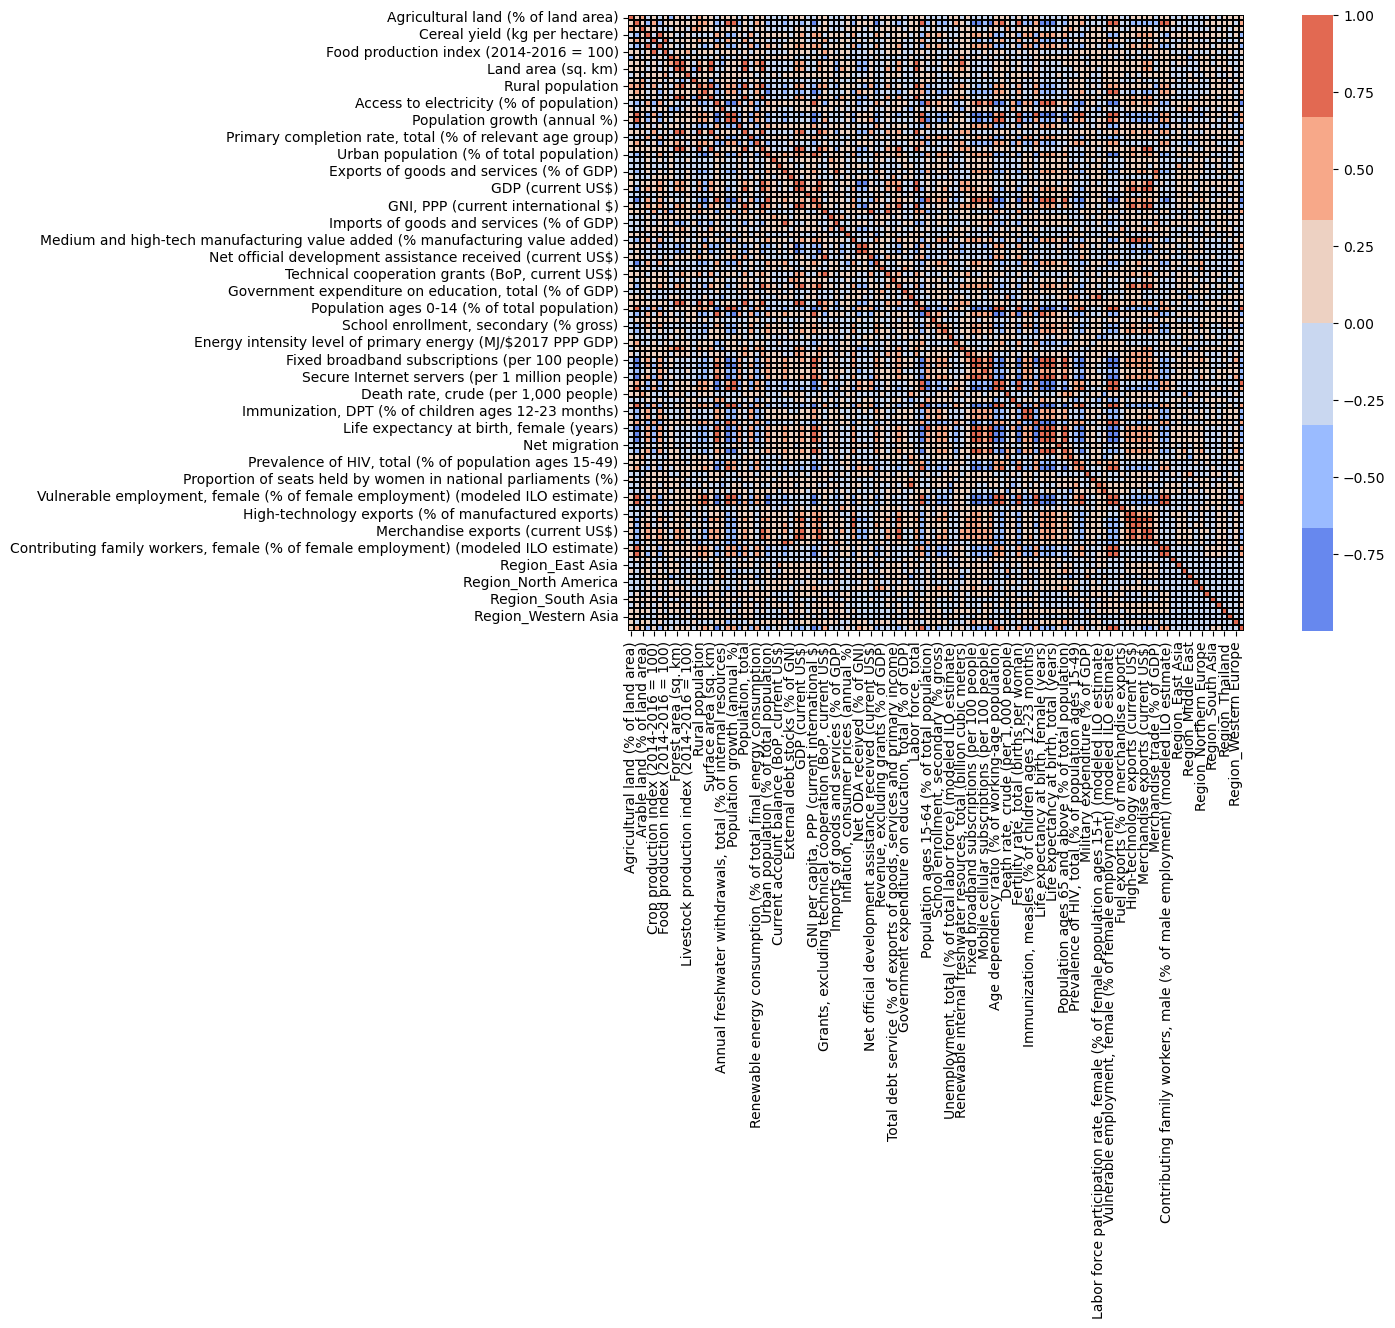

In [525]:
plt.figure(figsize=(15,8))
sns.heatmap(X_train.corr(),
            square=True,
            linewidths=0.25,    
            linecolor=(0,0,0),
            cmap=sns.color_palette("coolwarm"),
            annot=False)
plt.show()

In [526]:
def drop_high_corr_cols_with_target(X, y, threshold=0.8):
    corr = X.corr().abs()
    target_corr = X.apply(lambda col: col.corr(y)).abs()

    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    drop_cols = set()

    for col in upper.columns:
        if col in drop_cols:
            continue
        high_corr = upper[col][upper[col] > threshold].index
        for other in high_corr:
            if other in drop_cols:
                continue
            if target_corr[col] < target_corr[other]:
                drop_cols.add(col)
                break
            else:
                drop_cols.add(other)


    return list(drop_cols)

In [527]:
drop_cols = drop_high_corr_cols_with_target(X_train, y_train, threshold=0.8)

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [528]:
X_train.shape

(147, 80)

In [529]:
X_test.shape

(37, 80)

# Modeling 

In [530]:
# Function to compute performance classification metrics
def evaluate_performance(y_true, y_pred, average_val='macro'):

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=average_val)
    recall = recall_score(y_true, y_pred, average=average_val)
    f1 = f1_score(y_true, y_pred, average=average_val)

    from sklearn.metrics import confusion_matrix
    confusion = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, f1, confusion

In [531]:
from sklearn.preprocessing import StandardScaler

X_train_columns = X_train.columns
X_train_index = X_train.index
X_test_index = X_test.index

scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train_columns,
    index=X_train_index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_train_columns,
    index=X_test_index
)

In [532]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import f1_score


model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=3000,
    random_state=0
)

results = []

for k in range(10, 41, 5):
    rfe = RFE(model, n_features_to_select=k)
    rfe.fit(X_train, y_train)
    Xtr = X_train.loc[:, rfe.support_]
    Xte = X_test.loc[:, rfe.support_]

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    results.append((k, f1_score(y_test, y_pred, average="macro")))

In [533]:
results

[(10, 0.24708994708994708),
 (15, 0.15395622895622893),
 (20, 0.17965141612200436),
 (25, 0.2393162393162393),
 (30, 0.23819343229869547),
 (35, 0.2353015873015873),
 (40, 0.23922705314009662)]

In [534]:
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=3000,
    random_state=0
)

rfe = RFE(
    estimator=model,
    n_features_to_select=10,
    step=1
)

rfe.fit(X_train, y_train)

selected_features = X_train.columns[rfe.support_]

X_train = X_train[selected_features]
X_test = X_test[selected_features]

#######################################################
model.fit(X_train, y_train)

# Use model for predicted responses
y_pred = model.predict(X_test)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

[[4 3 0 0 0]
 [2 5 1 1 2]
 [1 1 1 2 1]
 [0 2 1 0 1]
 [2 5 0 1 1]]
0.2972972972972973 0.25805555555555554 0.2607503607503608 0.24708994708994708


# Performance evaluation

In [535]:
# Get summary of classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         1.0       0.44      0.57      0.50         7
         2.0       0.31      0.45      0.37        11
         3.0       0.33      0.17      0.22         6
         4.0       0.00      0.00      0.00         4
         5.0       0.20      0.11      0.14         9

    accuracy                           0.30        37
   macro avg       0.26      0.26      0.25        37
weighted avg       0.28      0.30      0.28        37

